# L1.13 — Navigation degradation

**Level 1 · Depth · 40 minutes**

**Goal.** You can make an error that continues across steps.

**Check at the end.** You can say why an outage needs a state and a noise draw does not.

> Level 1 uses no simulation loop. You call each module directly.
>
> The text in this course obeys ASD-STE100 Simplified Technical English.

## 1. Memory is the difference

Lesson L1.12 drew a fresh error at every measurement. Those draws are independent: a bad fix at one
tick tells you nothing about the next one.

A real receiver does not fail that way. It loses lock, stays degraded for some seconds or minutes,
and then recovers. That is **memory**, and memory needs state.

`NavEffect` is the seam for it:

```python
class NavEffect:
    def initial() -> object: ...                              # this effect's own state
    def evolve(own, aircraft, elapsed, rng) -> object: ...     # age it
    def quality(own, aircraft_id) -> NavQuality: ...           # what it does to this aircraft
```

The state is **opaque**. `GnssNavigation` holds it inside `NavState.effects` and never looks into
it. That is what lets you add an effect without changing the navigation model.

In [1]:
%matplotlib inline
import dataclasses

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = False
BLUE, RED, GREY, GREEN, ORANGE = "#1f77b4", "#d62728", "#7f7f7f", "#2ca02c", "#ff7f0e"

from opencdarr import M600, create_aircraft, generator, geo, root_seed_sequence
from opencdarr.cns import GnssNavigation, GnssOutage, NavQuality, gnss_outage
from opencdarr.cns.hazard import hazard

FLEET = [create_aircraft(M600, id=f"AC{k}", lat=52.0 + 0.01 * k, lon=4.0, trk=0.0, gs=10.0,
                         pos_ci95=10.0, vel_ci95=1.0)
         for k in range(3)]

outage = GnssOutage(fail_rate=60.0, recover_rate=200.0, pos_factor=20.0, vel_factor=20.0)
nav = GnssNavigation(effects=(outage,))

print(f"fail_rate     {outage.fail_rate:.0f} per hour")
print(f"recover_rate  {outage.recover_rate:.0f} per hour")
print(f"pos_factor    {outage.pos_factor:.0f}x   (a degraded fix is this much worse)")
print(f"declare       {outage.declare}   (does the broadcast admit it?)")
print(f"\ninitial state: {nav.initial_state()}")

fail_rate     60 per hour
recover_rate  200 per hour
pos_factor    20x   (a degraded fix is this much worse)
declare       True   (does the broadcast admit it?)

initial state: NavState(effects=(GnssOutageState(out=frozenset()),), t_prev=None)


## 2. Rates are per hour, and `evolve` takes the absolute time

Two details that are easy to get wrong, and both give you a silent zero if you do.

**The rate is per hour.** `hazard(rate, elapsed)` returns $1 - e^{-\text{rate}\cdot\text{elapsed}/3600}$.
The unit is per hour because that is how reliability is quoted: a mean time between failures of 28
hours is readable, and `1e-5` per second is not. `elapsed` stays in seconds.

**`evolve` takes `t`, not `dt`.** It works out the elapsed time itself, from the `t_prev` it carries.
Pass the same `t` twice and the elapsed time is zero, so nothing ever fails. Pass the absolute
clock.

The reason for that design: a broadcast schedule with a phase offset or jitter makes the gap between
calls something other than the nominal interval. Ageing over the real elapsed time gets that right
without the effect ever being told the cadence.

In [2]:
print(f"{'rate [1/h]':>12}{'over 1 s':>12}{'over 60 s':>12}{'mean time to fail':>21}")
for rate in (1.0, 60.0, 200.0, 3600.0):
    print(f"{rate:>12.0f}{hazard(rate, 1.0):>12.5f}{hazard(rate, 60.0):>12.5f}"
          f"{3600.0 / rate:>18.1f} s")

  rate [1/h]    over 1 s   over 60 s    mean time to fail
           1     0.00028     0.01653            3600.0 s
          60     0.01653     0.63212              60.0 s
         200     0.05404     0.96433              18.0 s
        3600     0.63212     1.00000               1.0 s


In [3]:
def timeline(model, n: int = 300, dt: float = 1.0, seed: int = 0):
    """Age the nav state over n steps. Returns the set of degraded ids at each step."""
    state = model.initial_state()
    stream = generator(root_seed_sequence(seed))
    out = []
    for k in range(n):
        state = model.evolve(state, FLEET, (k + 1) * dt, stream)   # ABSOLUTE time, not dt
        out.append(frozenset(gnss_outage(state).out))
    return out


history = timeline(nav)
for ac in FLEET:
    share = np.mean([ac.id in s for s in history])
    print(f"{ac.id} degraded for {share:.1%} of the run")
print(f"\nsteps with at least one aircraft degraded: "
      f"{np.mean([len(s) > 0 for s in history]):.1%}")

# the trap, made explicit
stuck = nav.initial_state()
stream = generator(root_seed_sequence(0))
for _ in range(300):
    stuck = nav.evolve(stuck, FLEET, 1.0, stream)      # the same t every call
print(f"\npassing t = 1.0 every call: {len(gnss_outage(stuck).out)} aircraft degraded after "
      f"300 steps  <- elapsed was 0")

AC0 degraded for 50.7% of the run
AC1 degraded for 42.0% of the run
AC2 degraded for 31.7% of the run

steps with at least one aircraft degraded: 82.0%

passing t = 1.0 every call: 0 aircraft degraded after 300 steps  <- elapsed was 0


## 3. What the effect does to a fix

`quality` returns a `NavQuality` with four multipliers:

| Field | What it scales |
| --- | --- |
| `pos_scale`, `vel_scale` | The accuracy the **error is drawn from**. The truth. |
| `pos_declared`, `vel_declared` | The accuracy the **broadcast claims**. |

A nominal receiver returns all ones, so an unaffected fix is bit-for-bit the one you would get with
no effect at all.

`declare=True` scales both, so the aircraft admits the degradation. `declare=False` scales only the
truth, so the aircraft keeps claiming its nominal accuracy while its fixes get 20 times worse. That
second case is the dangerous one, and it is the reason the two are separate fields.

In [4]:
honest = GnssNavigation(effects=(GnssOutage(fail_rate=60.0, recover_rate=200.0, declare=True),))
quiet = GnssNavigation(effects=(GnssOutage(fail_rate=60.0, recover_rate=200.0, declare=False),))

def sample(model, seed: int = 0, n: int = 400):
    """Age and measure together. Returns (degraded?, error [m], declared accuracy [m]) per step."""
    state = model.initial_state()
    stream = generator(root_seed_sequence(seed))
    rows = []
    for k in range(n):
        state = model.evolve(state, FLEET, float(k + 1), stream)
        msg = model.measure(state, FLEET[0], float(k + 1), stream)
        rows.append((FLEET[0].id in gnss_outage(state).out,
                     geo.qdrdist(FLEET[0].lat, FLEET[0].lon, msg.state.lat, msg.state.lon)[1],
                     msg.state.pos_ci95))
    return rows


for name, model in (("declare=True", honest), ("declare=False", quiet)):
    rows = sample(model)
    bad = [r for r in rows if r[0]]
    good = [r for r in rows if not r[0]]
    print(f"{name}")
    print(f"    nominal: median error {np.median([r[1] for r in good]):6.2f} m, "
          f"broadcast claims {good[0][2]:.0f} m")
    print(f"    degraded: median error {np.median([r[1] for r in bad]):6.2f} m, "
          f"broadcast claims {bad[0][2]:.0f} m")

declare=True
    nominal: median error   5.15 m, broadcast claims 10 m
    degraded: median error  97.28 m, broadcast claims 200 m
declare=False
    nominal: median error   5.15 m, broadcast claims 10 m
    degraded: median error  97.28 m, broadcast claims 10 m


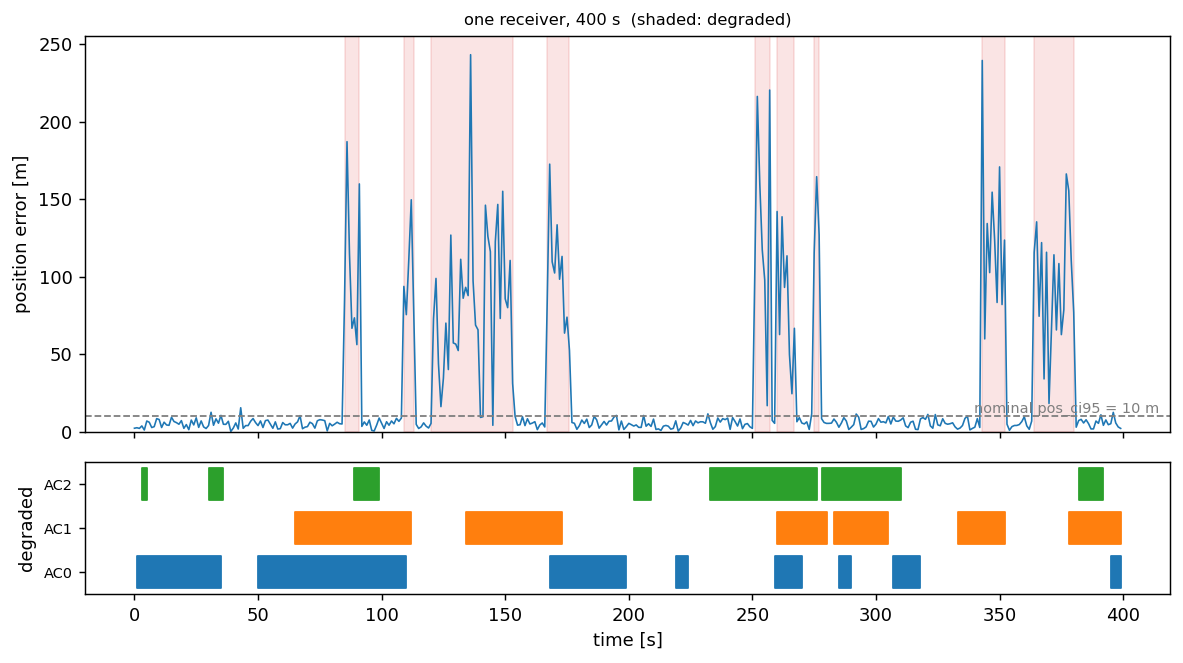

In [5]:
rows = sample(honest)
t = np.arange(len(rows))
degraded = np.array([r[0] for r in rows])
errors = np.array([r[1] for r in rows])

fig, (ax_e, ax_t) = plt.subplots(2, 1, figsize=(9.2, 5.2), sharex=True,
                                 gridspec_kw={"height_ratios": [3, 1]})

ax_e.fill_between(t, 0, errors.max() * 1.05, where=degraded, color=RED, alpha=0.12, step="mid")
ax_e.plot(t, errors, lw=0.9, color=BLUE)
ax_e.axhline(FLEET[0].pos_ci95, ls="--", lw=1.0, color=GREY)
ax_e.annotate(f"nominal pos_ci95 = {FLEET[0].pos_ci95:.0f} m", (0.99, FLEET[0].pos_ci95),
              xycoords=("axes fraction", "data"), ha="right", va="bottom", fontsize=8, color=GREY)
ax_e.set_ylim(0, errors.max() * 1.05)
ax_e.set_ylabel("position error [m]")
ax_e.set_title("one receiver, 400 s  (shaded: degraded)", fontsize=9)

full = timeline(nav, n=len(rows))
for k, ac in enumerate(FLEET):
    flags = np.array([ac.id in s for s in full])
    ax_t.fill_between(t, k, k + 0.72, where=flags, color=(BLUE, ORANGE, GREEN)[k], step="mid")
ax_t.set_yticks(np.arange(len(FLEET)) + 0.36)
ax_t.set_yticklabels([ac.id for ac in FLEET], fontsize=8)
ax_t.set_xlabel("time [s]")
ax_t.set_ylabel("degraded")
fig.tight_layout()

## 4. Write your own effect

Anything with memory fits this seam: a slow drift, a jamming region, a receiver that warms up. Three
methods, and the state is yours to shape.

Keep two rules:

1. The state must be a **value**, not a mutable object you hold on to. It is cloned with the
   particle in Level 6, and a clone must be independent of its source.
2. `quality` must return all ones for an aircraft that is not affected. That is what keeps an
   unaffected fix identical to the no-effect case.

In [6]:
@dataclasses.dataclass(frozen=True)
class WarmupState:
    """How long each receiver has been running [s]."""

    elapsed: float = 0.0


class Warmup:
    """A receiver that starts bad and improves — `factor` decays with a time constant `tau`."""

    def __init__(self, factor: float = 6.0, tau: float = 60.0) -> None:
        self.factor, self.tau = factor, tau

    def initial(self) -> WarmupState:
        return WarmupState()

    def evolve(self, own, aircraft, elapsed, rng) -> WarmupState:
        return WarmupState(elapsed=own.elapsed + elapsed)      # no draw: it is deterministic

    def quality(self, own, aircraft_id: str) -> NavQuality:
        scale = 1.0 + (self.factor - 1.0) * np.exp(-own.elapsed / self.tau)
        return NavQuality(pos_scale=scale, vel_scale=scale,
                          pos_declared=scale, vel_declared=scale)


warm = GnssNavigation(effects=(Warmup(),))
state = warm.initial_state()
stream = generator(root_seed_sequence(5))
print(f"{'t [s]':>7}{'declared accuracy':>21}")
for k in range(241):
    state = warm.evolve(state, FLEET, float(k), stream)
    if k % 40 == 0:
        msg = warm.measure(state, FLEET[0], float(k), stream)
        print(f"{k:>7}{msg.state.pos_ci95:>19.2f} m")

  t [s]    declared accuracy
      0              60.00 m
     40              35.67 m
     80              23.18 m
    120              16.77 m
    160              13.47 m
    200              11.78 m
    240              10.92 m


## Do it yourself

1. Set `recover_rate=0.0`. A receiver that fails never comes back. Check the timeline.
2. Set `fail_rate` so that the mean time to failure is 10 s. Use `3600 / rate`.
3. Give `GnssNavigation` **two** effects at once. Read `_quality_for` and say how they combine.
4. Add a draw to `Warmup.evolve` so that the warm-up time is random for each receiver.

## Check

1. Why does an outage need a state, and a noise draw does not?
2. Why is the rate per hour and the elapsed time in seconds?
3. `declare=False`. What does the aircraft broadcast, and why is that the dangerous case?

## Next

`L1.14 — CNS: communication`. The aircraft measures itself. Next the measurement has to reach
somebody.